In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag90Pd10_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    sigma_exp = wp.log_rate_SD_obs 
    sigma_tot = pm.math.sqrt(sigma_rel**2 + sigma_exp**2)
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_tot, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.9

# BF (!)
Good model. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.21,55
,3000,0,0.19,63
,3000,0,0.18,39
,3000,0,0.20,47


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   544.01    62.73
p_loo        7.92        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



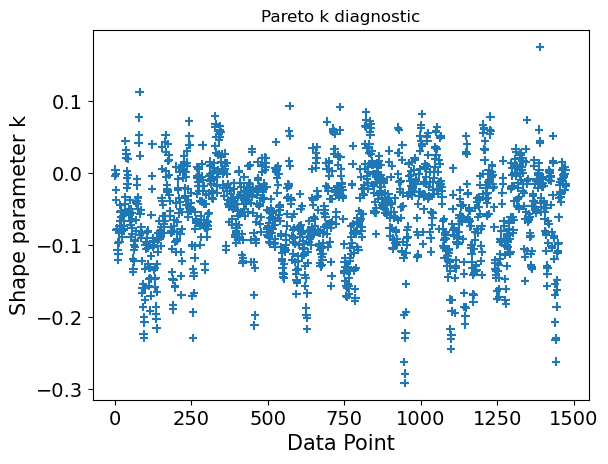

Sampling: [Gact2_0, beta_2, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.097  0.001  -0.098   -0.095        0.0      0.0    2078.0    2286.0    1.0
deltaG4_0  0.071  0.003   0.064    0.077        0.0      0.0    1345.0    1629.0    1.0
deltaG5_0 -0.022  0.003  -0.027   -0.015        0.0      0.0    1300.0    1671.0    1.0
beta_2     0.076  0.017   0.044    0.105        0.0      0.0    1186.0    1462.0    1.0
q          0.316  0.017   0.285    0.347        0.0      0.0    1161.0    1422.0    1.0
Gact2_0    0.698  0.001   0.696    0.701        0.0      0.0    1268.0    1752.0    1.0
sigma_rel  0.328  0.008   0.312    0.344        0.0      0.0    4670.0    2597.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
deltaG5_0: 1.000
beta_2: 0.997
q: 0.997
Gact2_0: 1.000
sigma_rel: 0.980


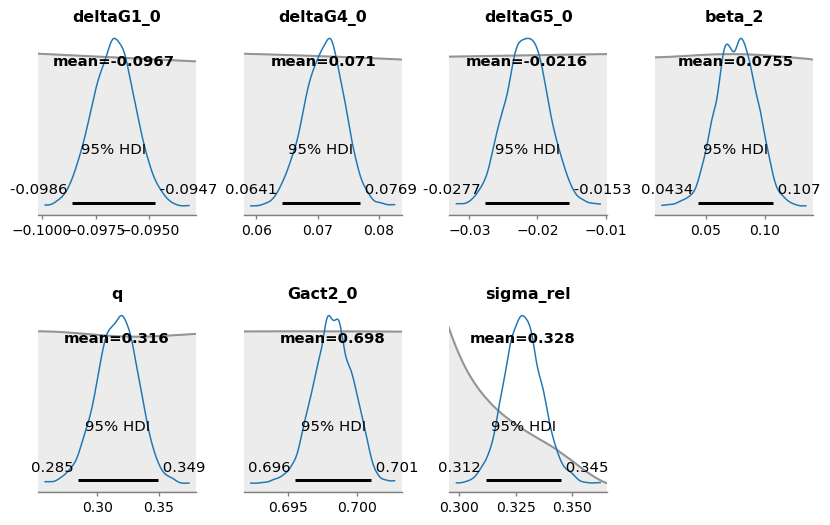

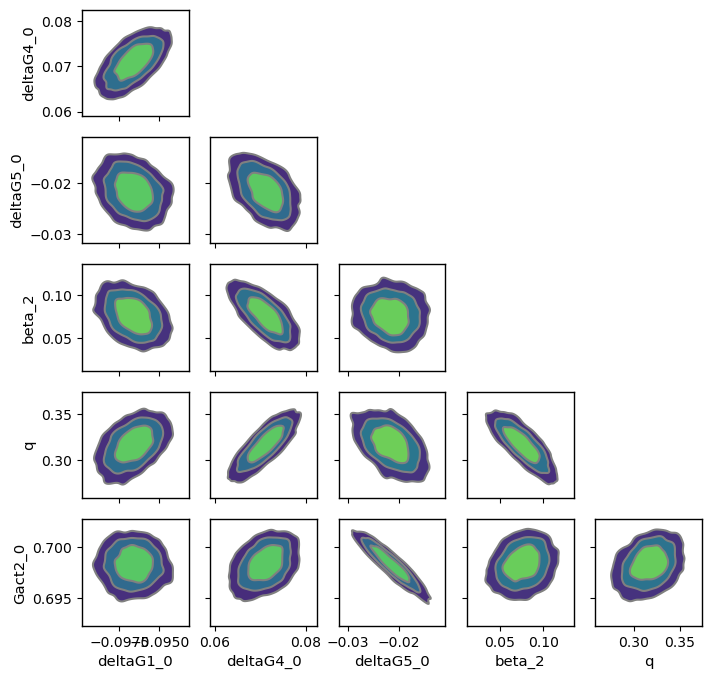

Sampling: [rate]


rate: 0.705


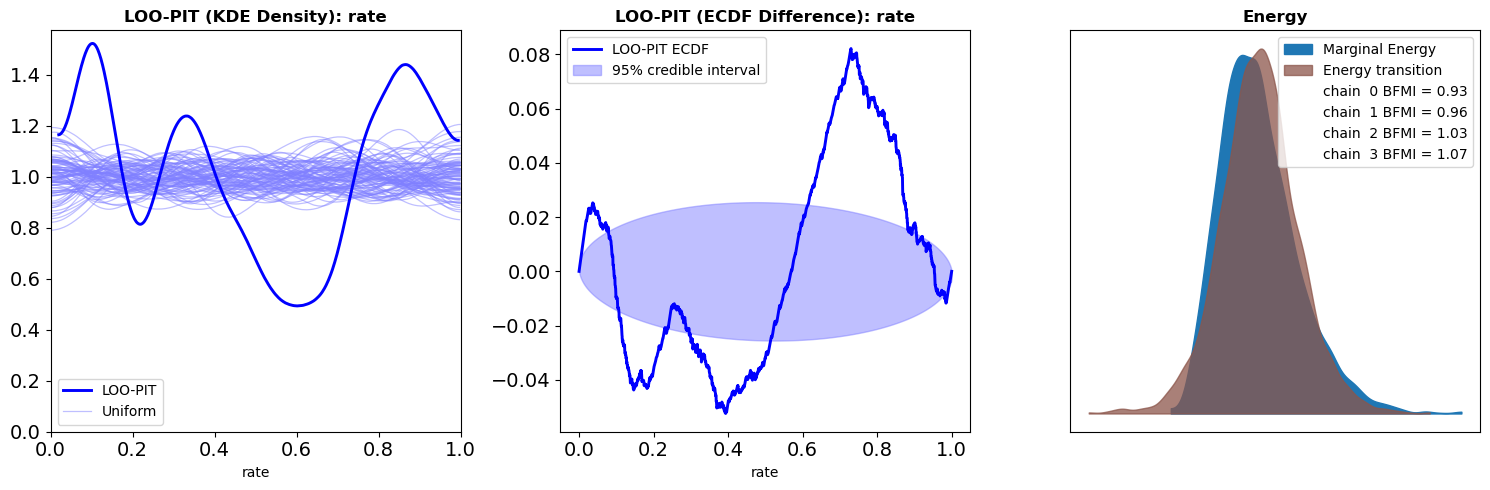

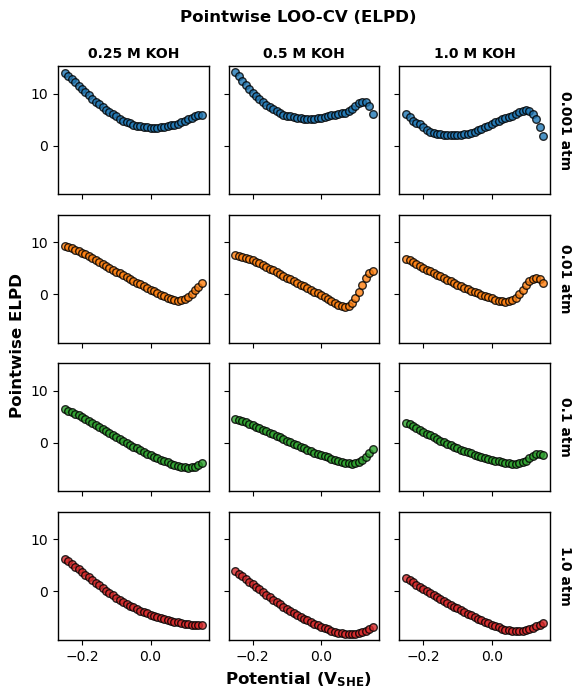

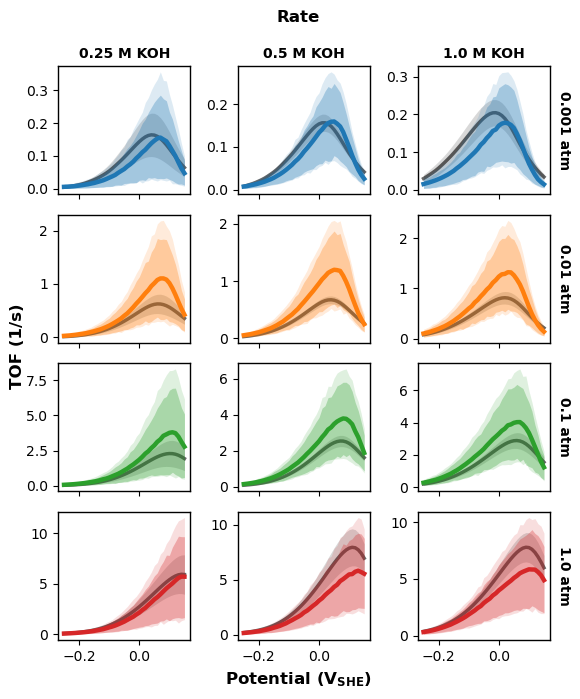

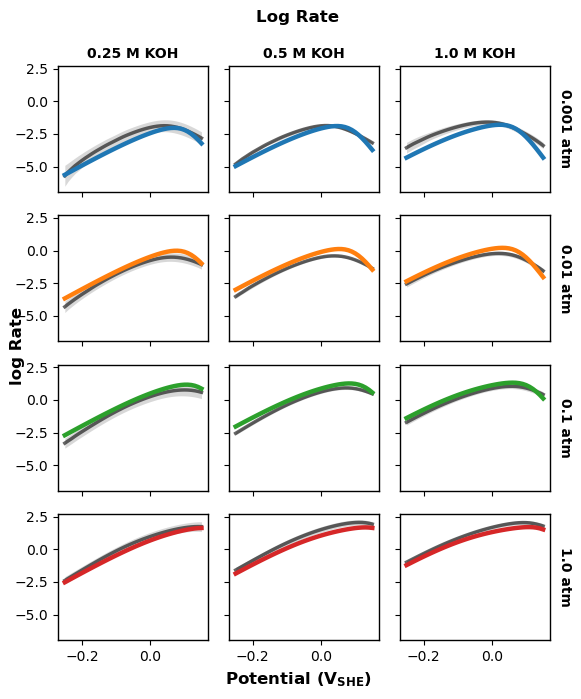

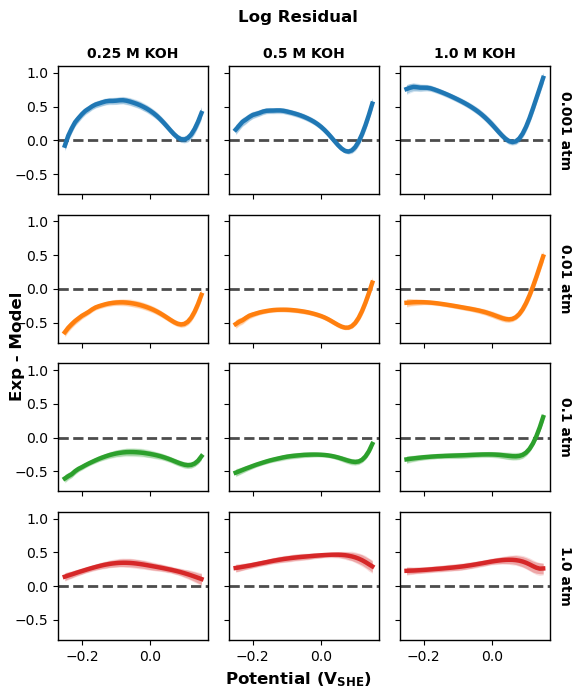

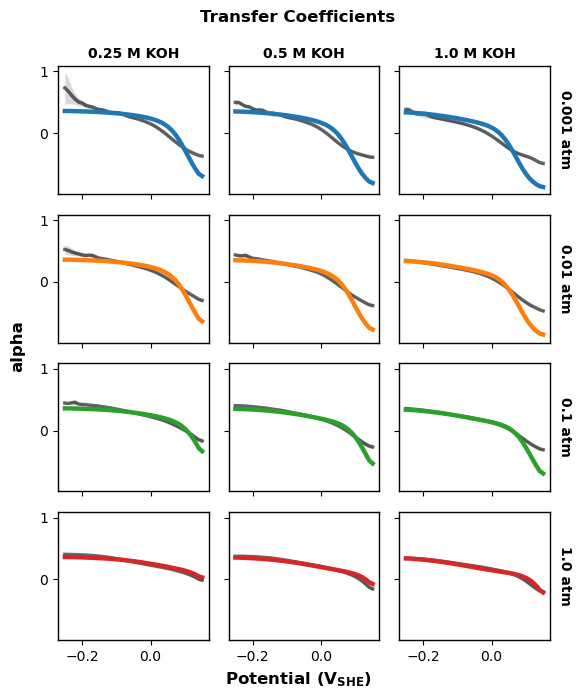

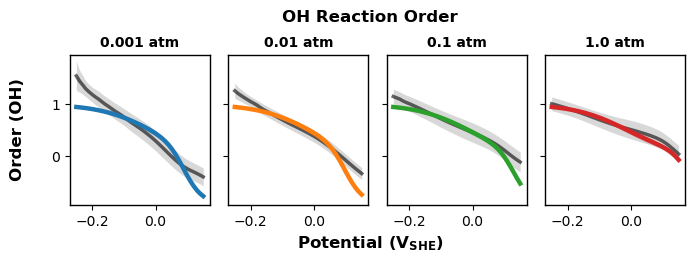

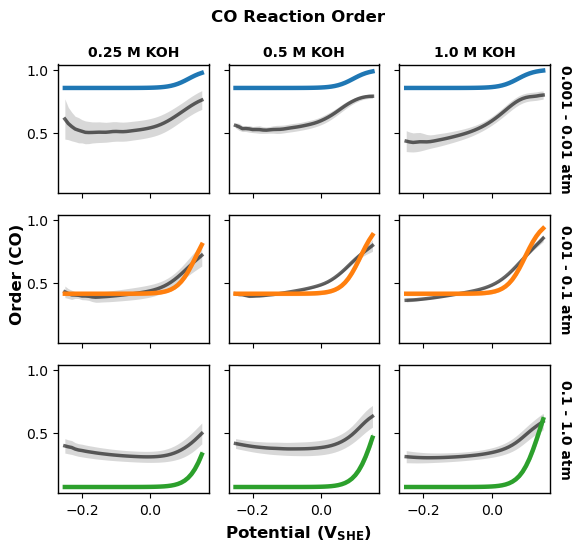

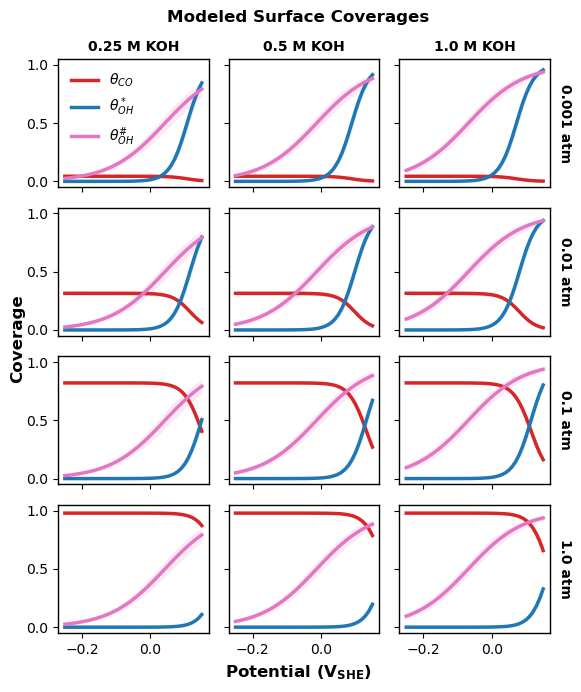

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)   
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF, target_accept=0.95)

ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF, loo_BF); plot_coverages(trace_BF)

# BF ER (!!)
Higher ELPD. ER has significant DRC. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.15,63
,3000,0,0.15,63
,3000,0,0.15,31
,3000,0,0.15,63


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   605.06    63.13
p_loo        8.01        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



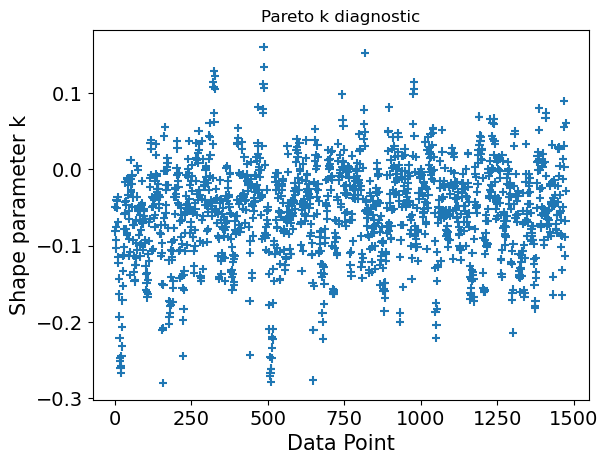

Sampling: [Gact2_BF_0, Gact2_ER_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.099  0.001  -0.100   -0.097      0.000    0.000    3165.0    2894.0    1.0
deltaG4_0   0.055  0.003   0.050    0.060      0.000    0.000    2610.0    2628.0    1.0
deltaG5_0  -0.030  0.003  -0.036   -0.023      0.000    0.000     857.0    1460.0    1.0
beta_2_BF   0.011  0.010   0.000    0.030      0.000    0.000    1692.0    1660.0    1.0
beta_2_ER   0.727  0.078   0.587    0.880      0.003    0.001     766.0    1321.0    1.0
q           0.384  0.011   0.363    0.406      0.000    0.000    1162.0    1903.0    1.0
Gact2_BF_0  0.703  0.002   0.700    0.707      0.000    0.000     776.0     961.0    1.0
Gact2_ER_0  0.786  0.012   0.765    0.809      0.000    0.000     737.0    1226.0    1.0
sigma_rel   0.309  0.008   0.294    0.325      0.000    0.000    5754.0    2771.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
deltaG5_0: 1.000
beta_2_BF: 0.999
be

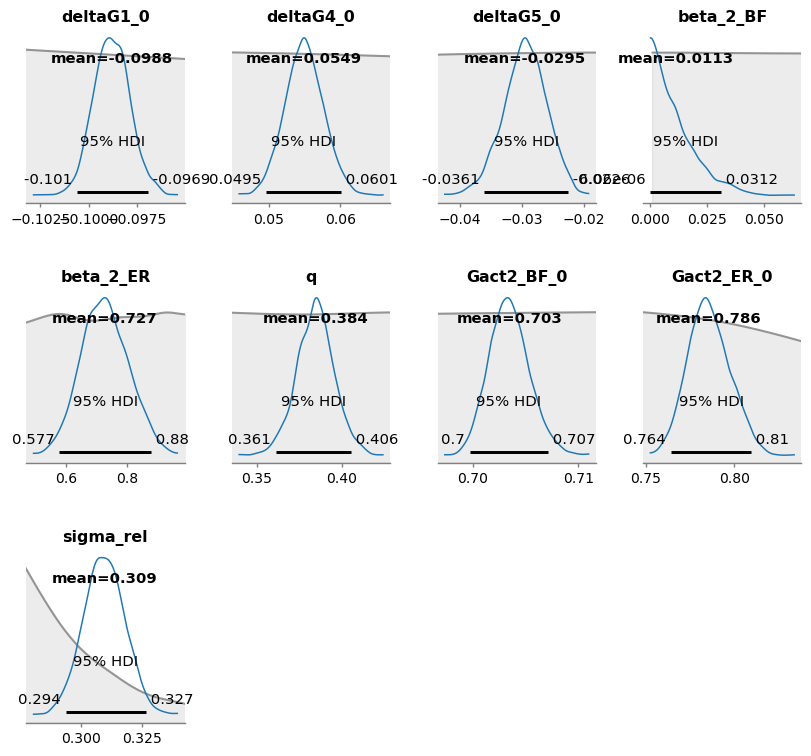

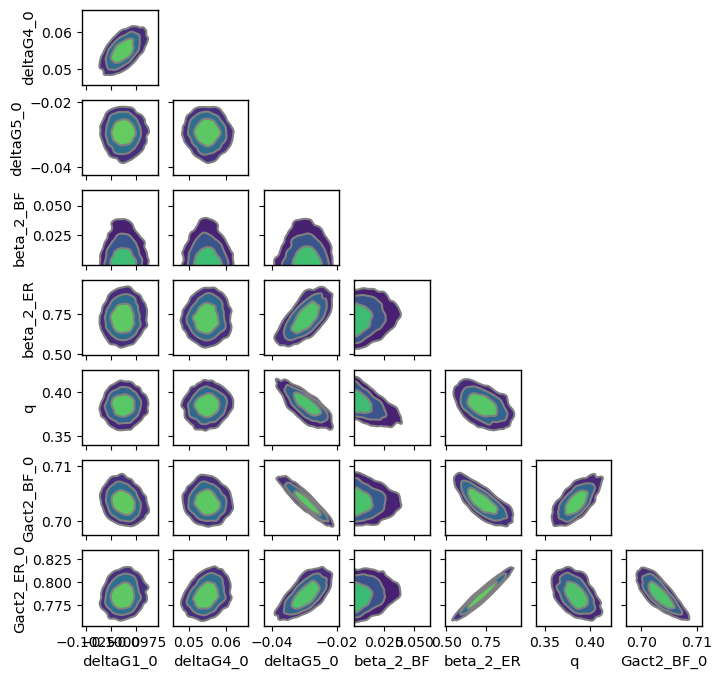

Sampling: [rate]


rate: 0.736


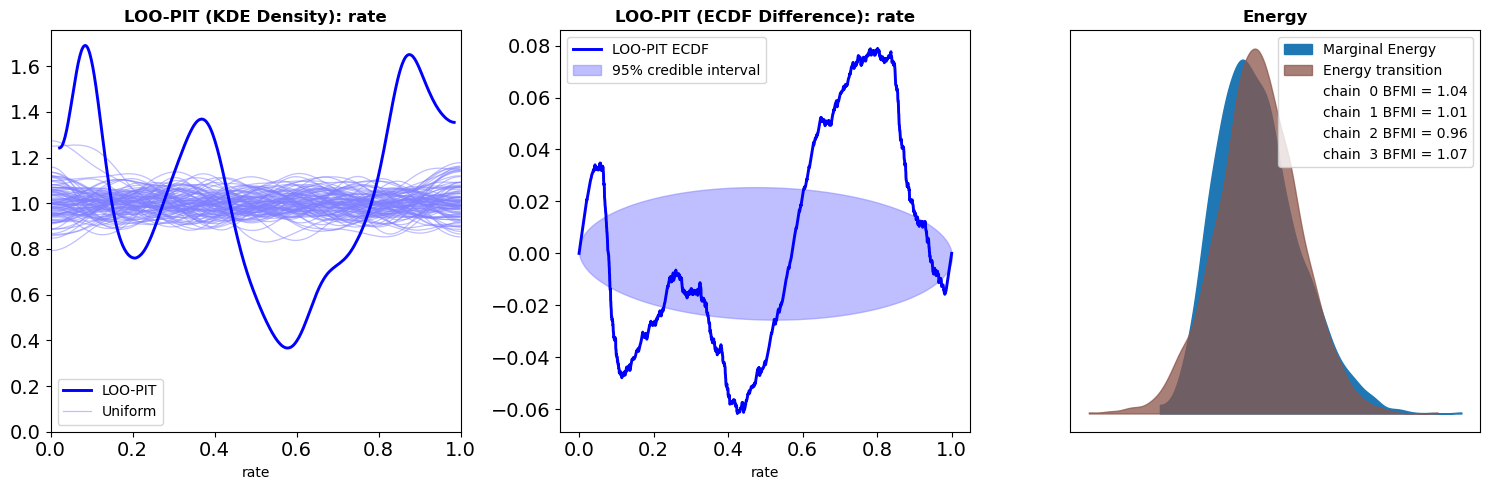

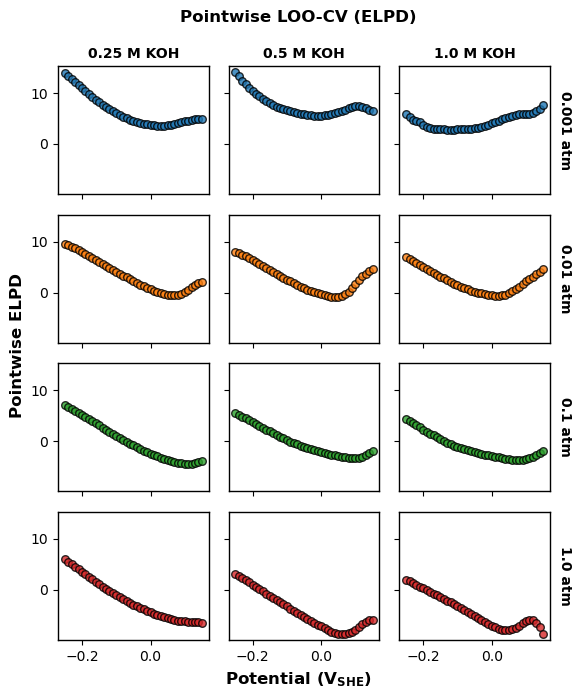

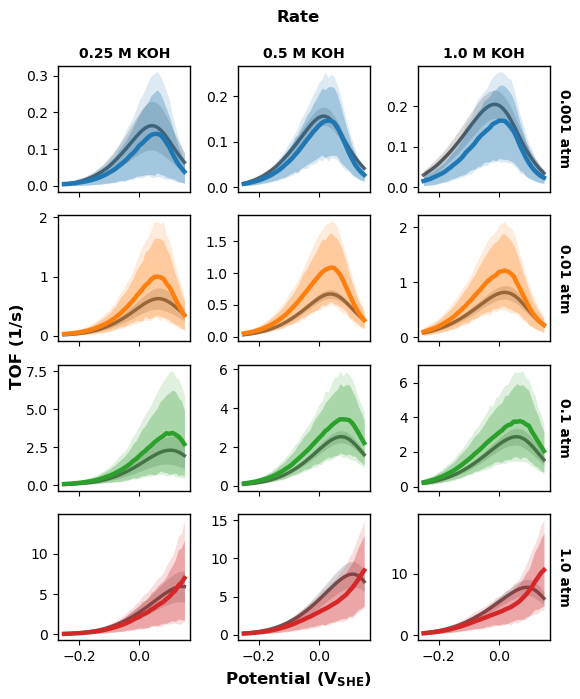

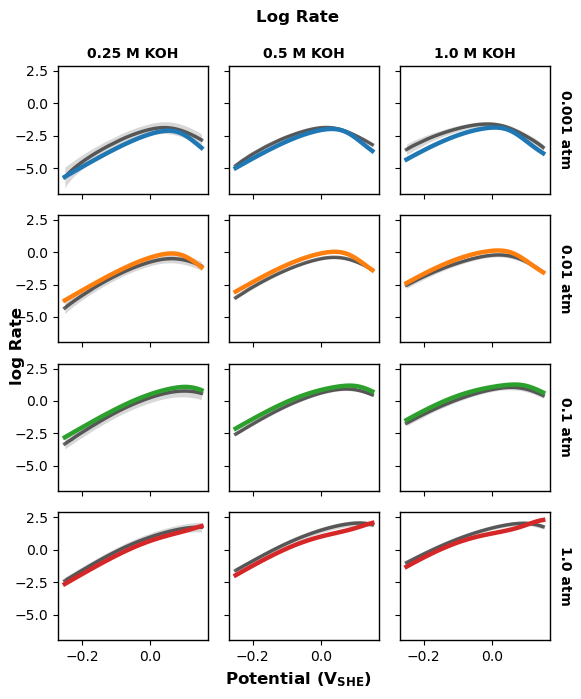

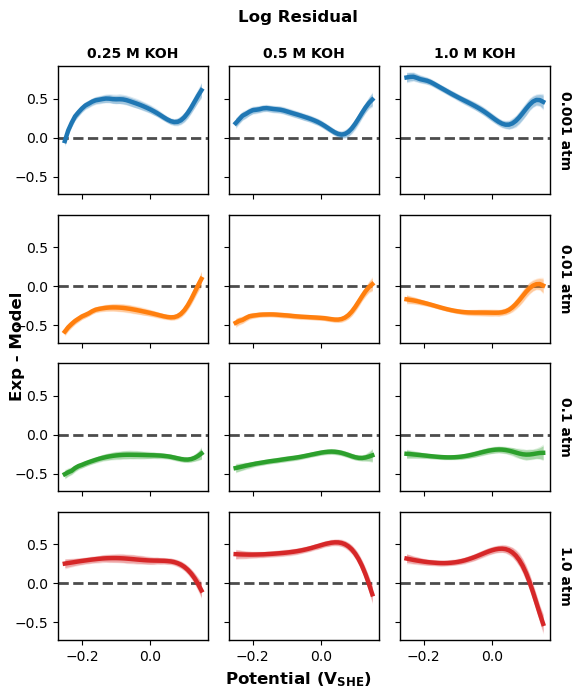

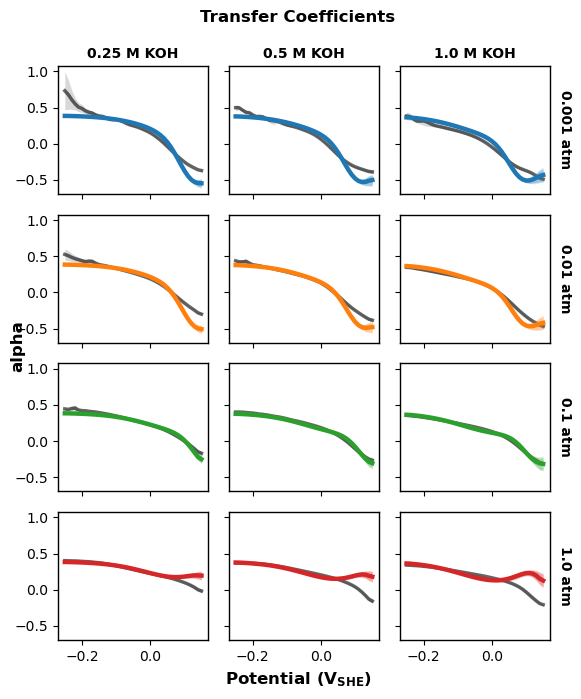

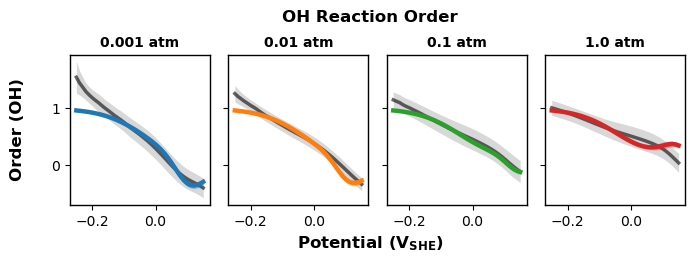

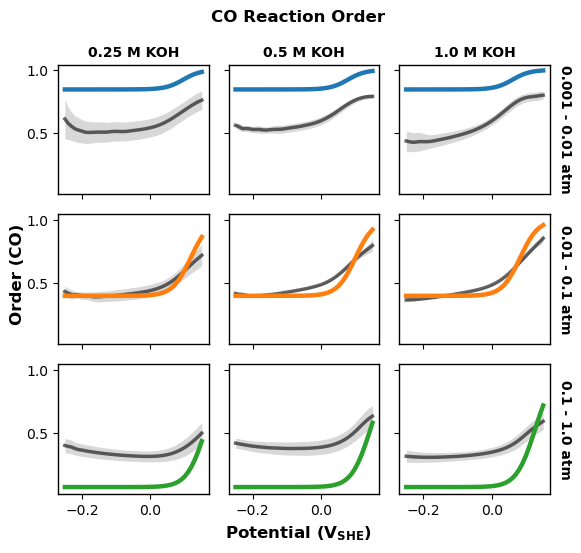

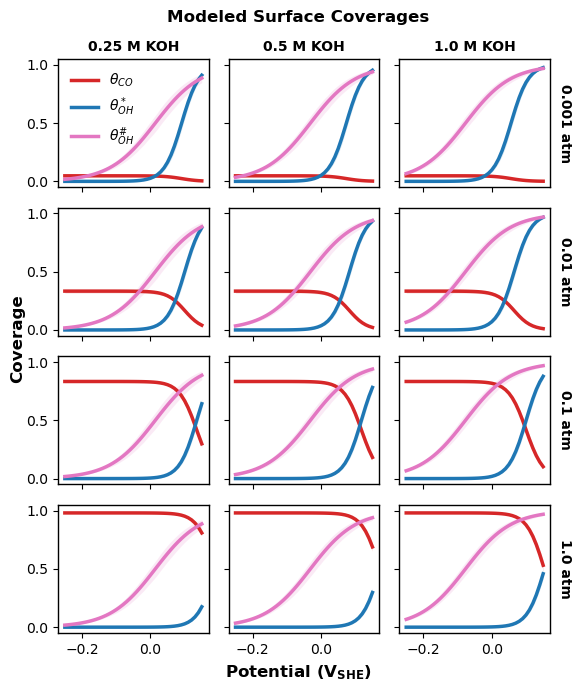

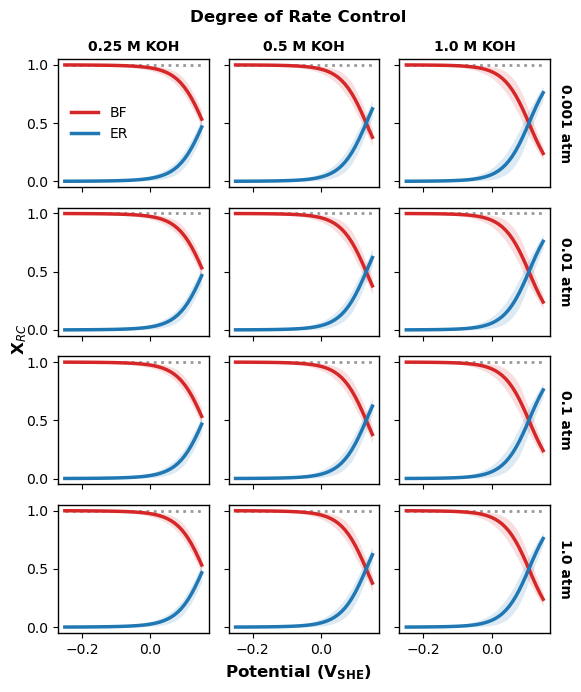

In [3]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2)
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0) # upper=0.4 
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER, target_accept=0.95)

ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER, loo_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# Final

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.09,127
,4000,4,0.10,63
,4000,2,0.10,63
,4000,15,0.13,63


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Computed from 8000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   600.71    63.00
p_loo       15.84        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



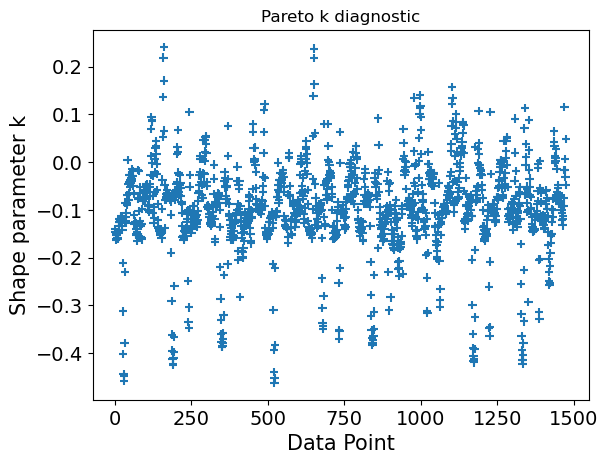

Sampling: [Gact1_0, Gact2_BF_0, Gact2_ER_0, Gact2_LH_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.059  0.011   0.049    0.091      0.003    0.003      39.0      31.0   1.08
deltaG5_0  -0.030  0.005  -0.038   -0.021      0.000    0.001     483.0      51.0   1.03
deltaG1_0  -0.100  0.002  -0.106   -0.097      0.001    0.001      39.0      31.0   1.08
beta_2_BF   0.013  0.013   0.000    0.033      0.001    0.002     684.0     149.0   1.01
beta_2_ER   0.699  0.155   0.239    0.885      0.032    0.039      64.0      31.0   1.06
q           0.391  0.025   0.352    0.433      0.005    0.007      59.0      33.0   1.06
Gact1_0     0.446  0.106   0.255    0.610      0.016    0.004      33.0      31.0   1.09
Gact2_BF_0  0.704  0.003   0.698    0.709      0.000    0.001     360.0      39.0   1.05
Gact2_ER_0  0.783  0.019   0.730    0.812      0.003    0.004     115.0      33.0   1.06
Gact2_LH_0  0.849  0.074   0.728    0.983      0.001    0.001    3979.0    2432.0   1.00
sigma_rel   0.309  0.

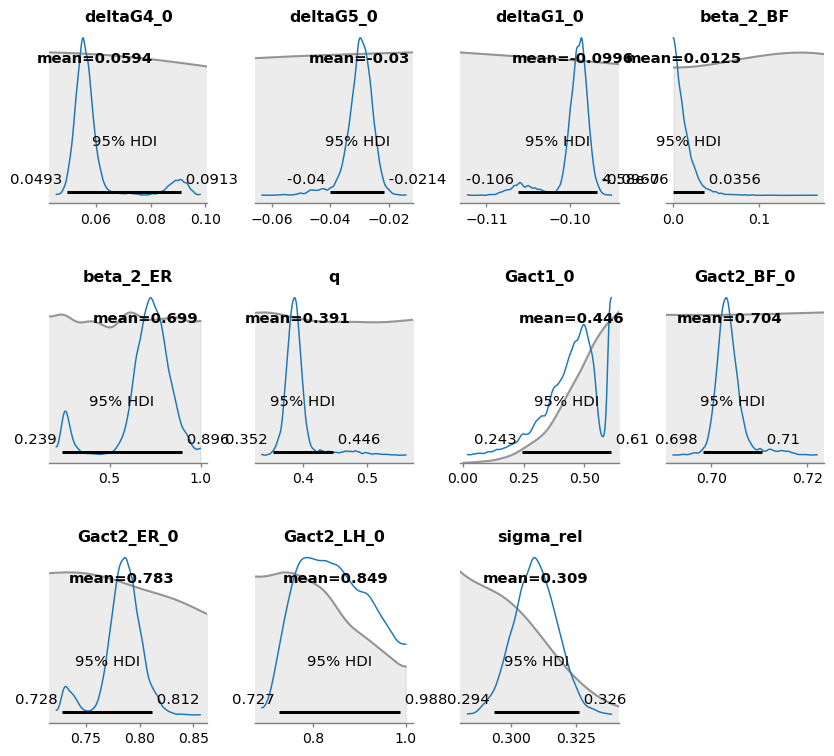

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


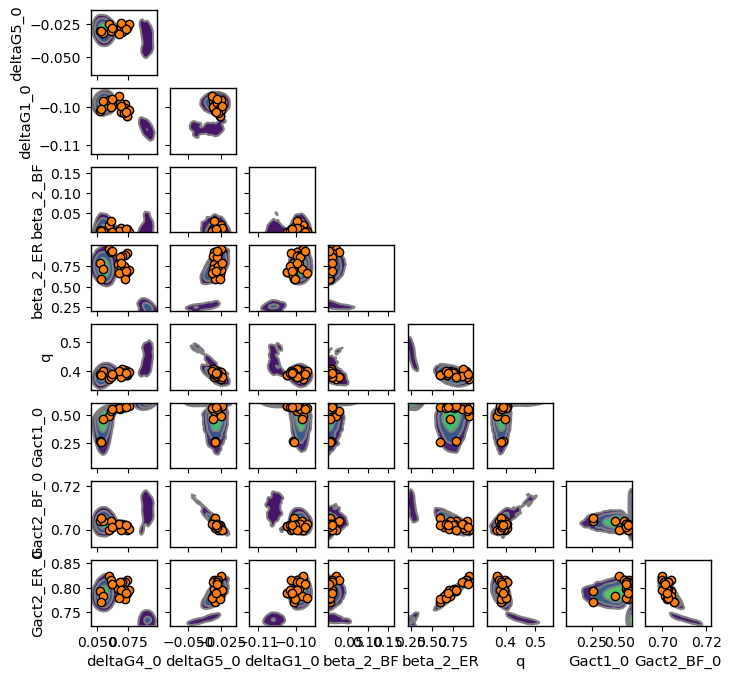

Sampling: [rate]


rate: 0.736


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:1057: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


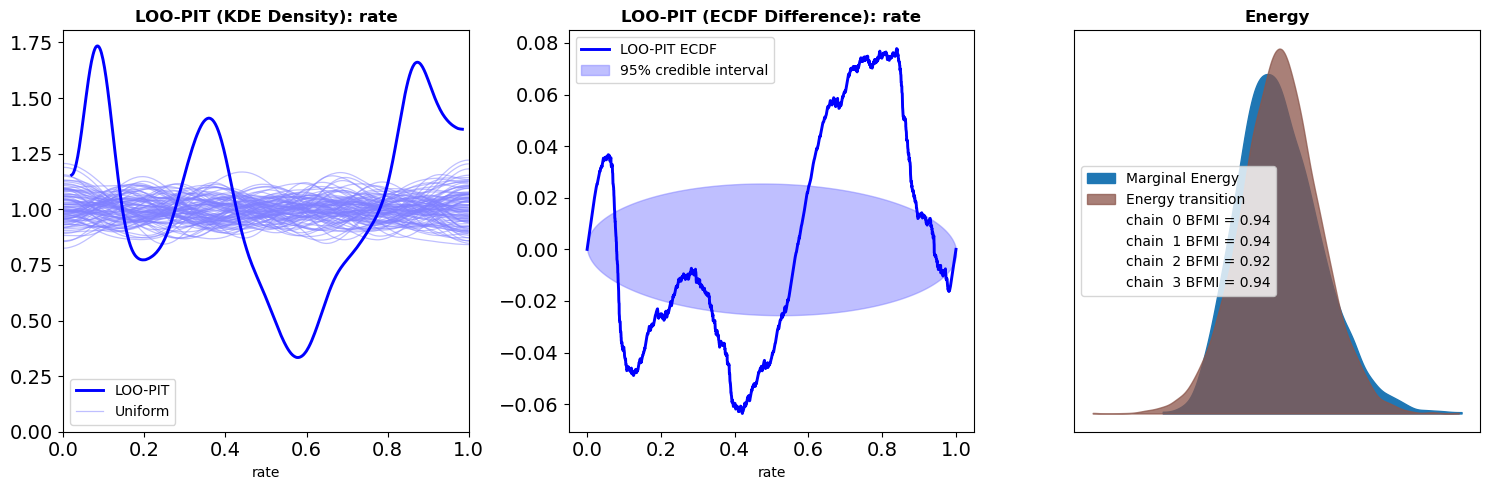

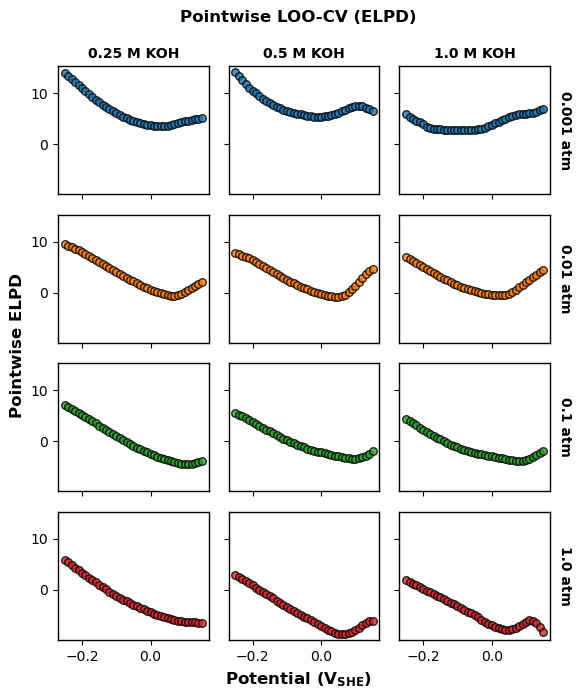

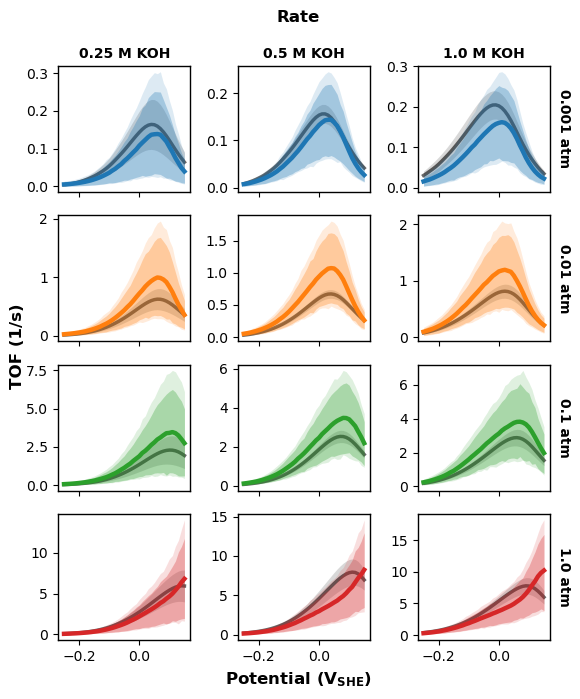

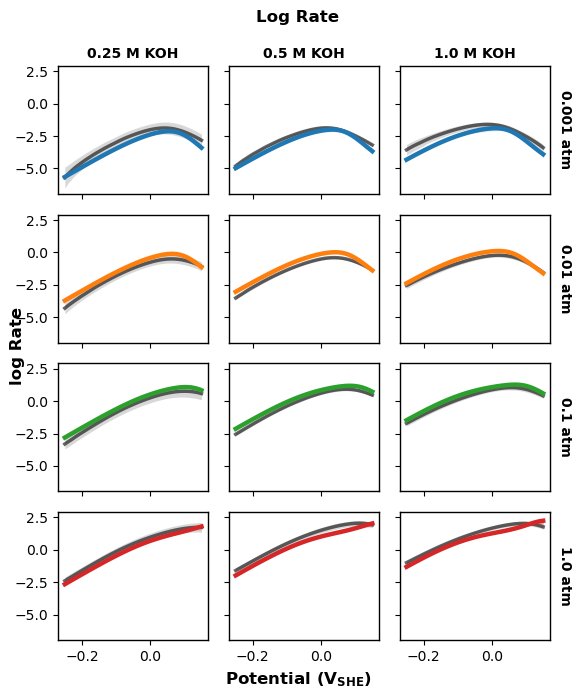

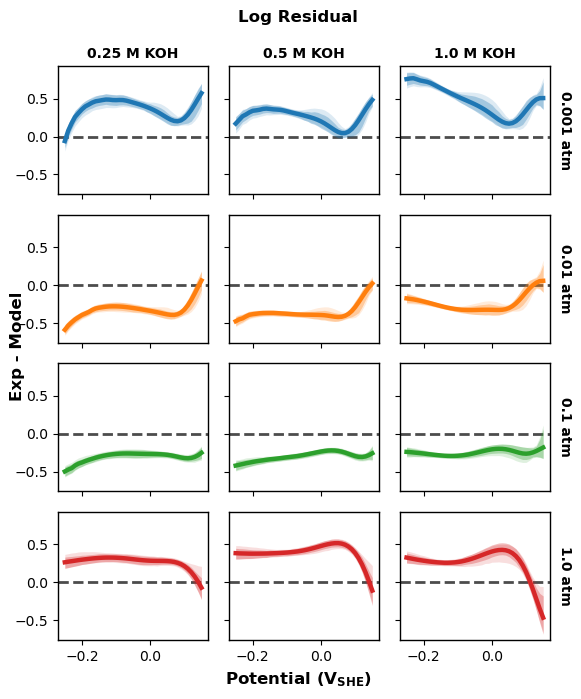

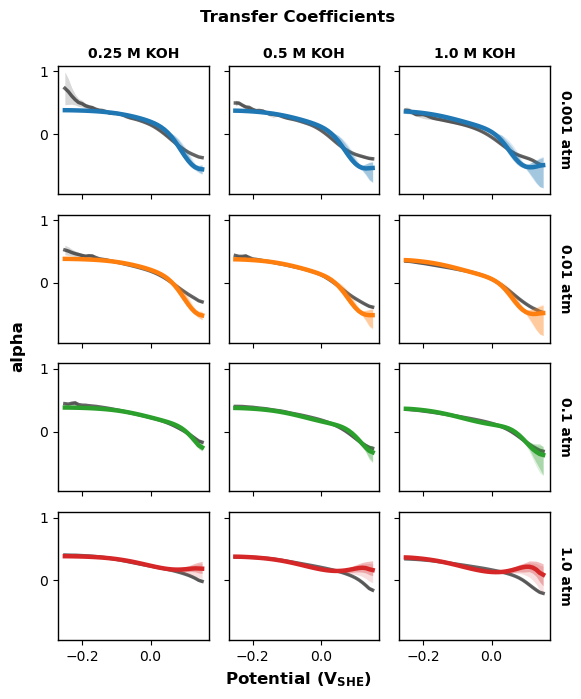

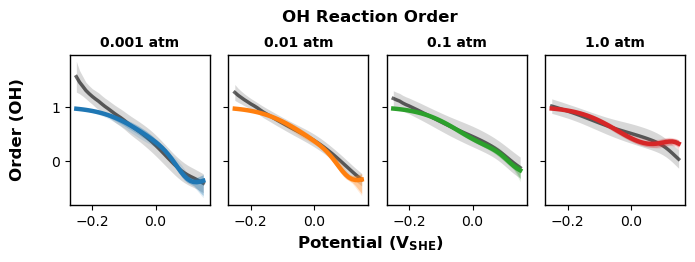

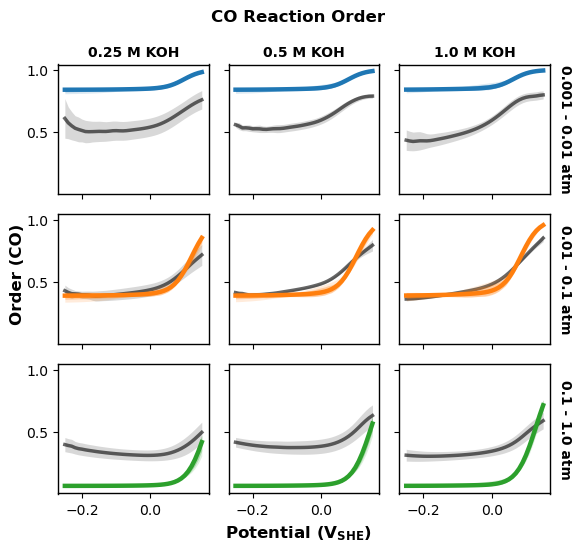

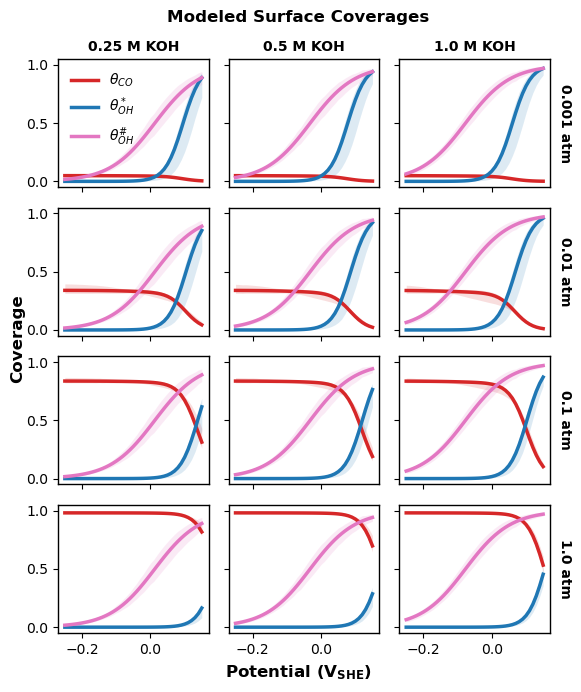

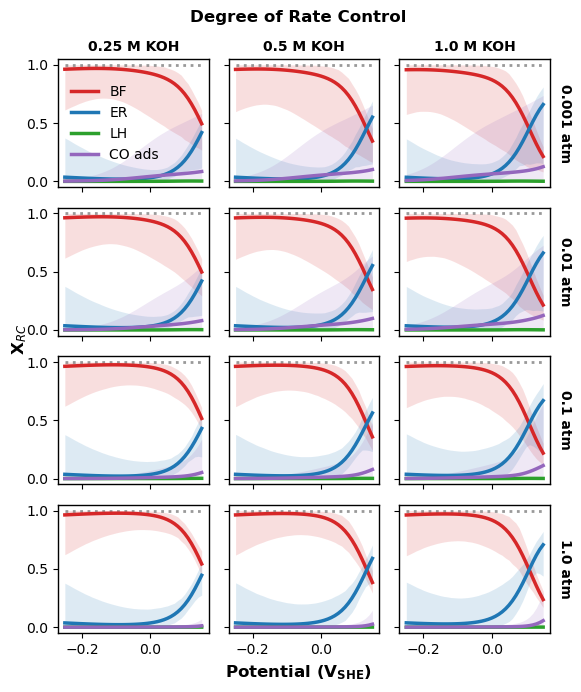

In [4]:
with pm.Model() as CO_BF_ER_LH:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA) (BF)
    2b. CO* + OH- -> COOH* + * + (e-) (SSA) (ER)
    2c. CO* + OH* -> COOH* + * (SSA) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.4, sigma=0.2, upper=0.0, lower=-0.4)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2_BF + log_theta_OH_Ag + np.log(Ag_comp)     
    log_k_ER_app = log_k2_ER + np.log(C_KOH_in)
    log_k_LH_app = log_k2_LH + term_OH_Pd + np.log(1.0 - Ag_comp) 

    # Quadratic solution for empty Pd site fraction
    k1_PCO = pt.exp(log_k1_PCO)
    A_Pd = pt.exp(log_A_Pd)
    log_k_cons = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_minus_1)
    k_cons = pt.exp(log_k_cons)
    k_LH_app = pt.exp(log_k_LH_app)
    a = k_LH_app * A_Pd
    b = k1_PCO + k_cons * A_Pd - k_LH_app
    c = -k_cons
    theta_empty_Pd_val = (2 * c) / (-b - pt.sqrt(b**2 - 4 * a * c)) # Analytical solution to quadratic SSA
    log_theta_Pd = pt.log(theta_empty_Pd_val)
    log_theta_CO = pt.log(1.0 - A_Pd * theta_empty_Pd_val)
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_k_total_app = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_LH_app + log_theta_Pd) 
    log_rate = log_k_total_app + log_theta_CO
    rate = observables(log_rate)

trace_CO_BF_ER_LH, loo_CO_BF_ER_LH = fit_and_evaluate(CO_BF_ER_LH, target_accept=0.95, draws=2000)

ppc_CO_BF_ER_LH = plot_posteriors(trace_CO_BF_ER_LH, CO_BF_ER_LH)
plot_model_fits(trace_CO_BF_ER_LH, ppc_CO_BF_ER_LH, loo_CO_BF_ER_LH); plot_coverages(trace_CO_BF_ER_LH)
plot_drc(CO_BF_ER_LH, trace_CO_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0', 'Gact1_0'], perturb_labels=['BF', 'ER', 'LH', 'CO ads'])

# Comparison

             rank    elpd_loo      p_loo  elpd_diff        weight         se       dse  warning scale
BF_ER           0  605.063038   8.007610   0.000000  1.000000e+00  63.129222  0.000000    False   log
CO_BF_ER_LH     1  600.709281  15.844090   4.353756  7.208928e-11  62.997127  1.259232    False   log
BF              2  544.009834   7.917995  61.053204  0.000000e+00  62.726532  9.114944    False   log


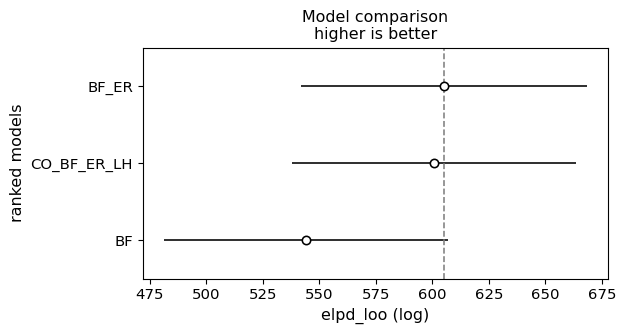

In [5]:
comparison_dict = {
    "BF": loo_BF, 
    "BF_ER": loo_BF_ER,
    "CO_BF_ER_LH": loo_CO_BF_ER_LH
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()